In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results__.html
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/final_dataset.xlsx
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__notebook__.ipynb
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__output__.json
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/custom.css
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___15_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___14_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___22_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___16_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___17_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___13_0.png


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results__.html
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/final_dataset.xlsx
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__notebook__.ipynb
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__output__.json
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/custom.css
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___15_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___14_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___22_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___16_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___17_0.png
/kaggle/input/notebooks/fareselgohary003/superstore-dataset/__results___files/__results___13_0.png


In [3]:
import pandas as pd

data = pd.read_excel("/kaggle/input/notebooks/fareselgohary003/superstore-dataset/final_dataset.xlsx")

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Year,Month,Month Name,Shipping Days,Profit Margin,Order Month,Cohort,Customer Type
0,7981,CA-2014-103800,2014-01-03,2014-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,0.2,5.5512,2014,1,January,4,0.3375,2014-01,2014-01,Medium Value
1,740,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.2,4.2717,2014,1,January,4,0.3625,2014-01,2014-01,Low Value
2,741,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.2,-64.7748,2014,1,January,4,-0.2375,2014-01,2014-01,Low Value
3,742,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.8,-5.4870,2014,1,January,4,-1.5500,2014-01,2014-01,Low Value
4,1760,CA-2014-141817,2014-01-05,2014-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,0.2,4.8840,2014,1,January,7,0.2500,2014-01,2014-01,Low Value


In [4]:
data.shape


(9994, 29)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
data.head()

data.info()

data.describe()

data.columns

data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int64
Month                     int64
Month Name               object
Shipping Days             int64
Profit Margin           float64
Order Month              object
Cohort                   object
Customer Type            object
dtype: object

In [7]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month Name       0
Shipping Days    0
Profit Margin    0
Order Month      0
Cohort           0
Customer Type    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Month Name', 'Shipping Days', 'Profit Margin', 'Order Month',
       'Cohort', 'Customer Type'],
      dtype='object')

1. Sales by Category


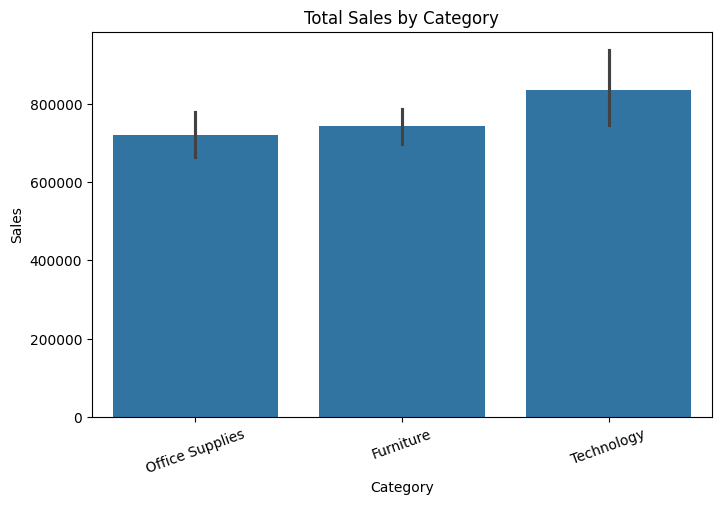

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=data, estimator=sum)
plt.title("Total Sales by Category")
plt.xticks(rotation=20)
plt.show()

2. Profit by Category

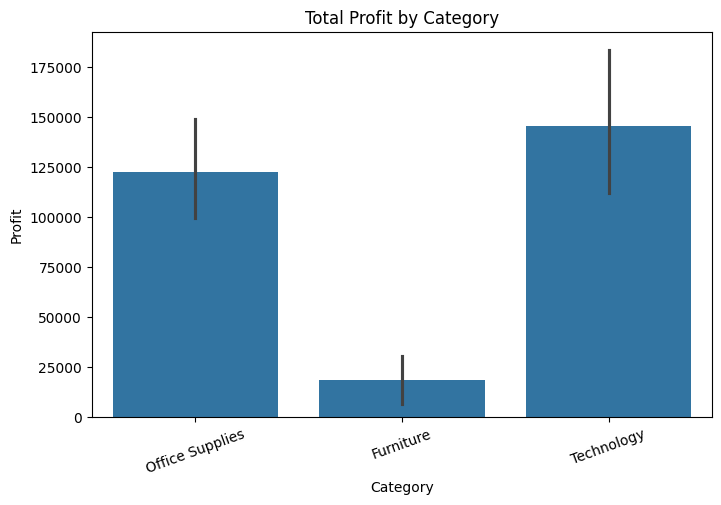

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=data, estimator=sum)
plt.title("Total Profit by Category")
plt.xticks(rotation=20)
plt.show()

3. Sales by Region

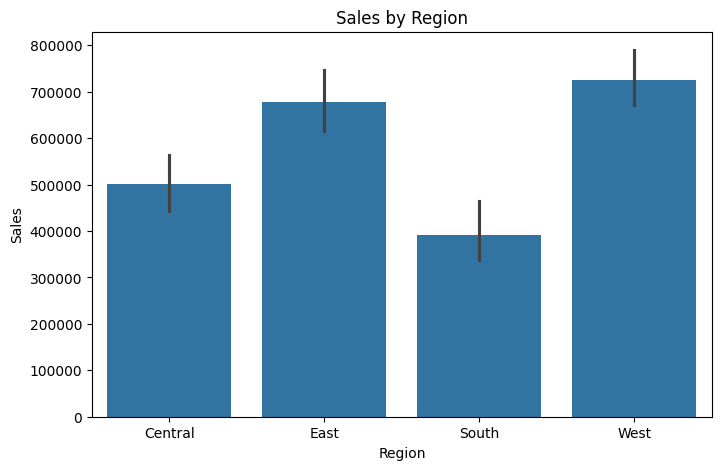

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=data, estimator=sum)
plt.title("Sales by Region")
plt.show()

4. Profit by Region

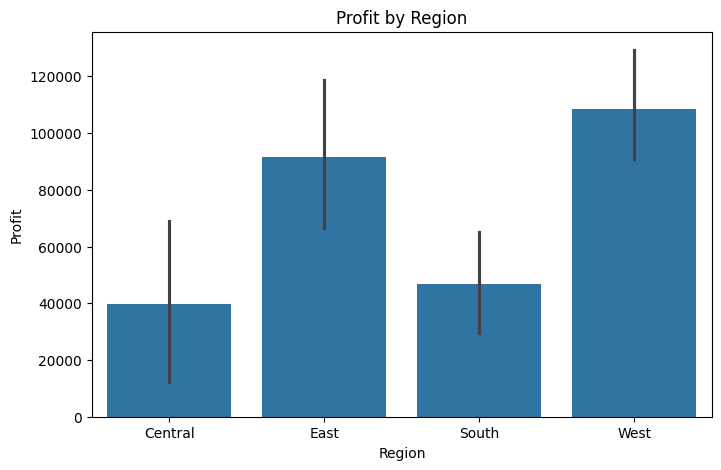

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Profit', data=data, estimator=sum)
plt.title("Profit by Region")
plt.show()

5. Monthly Sales Trend

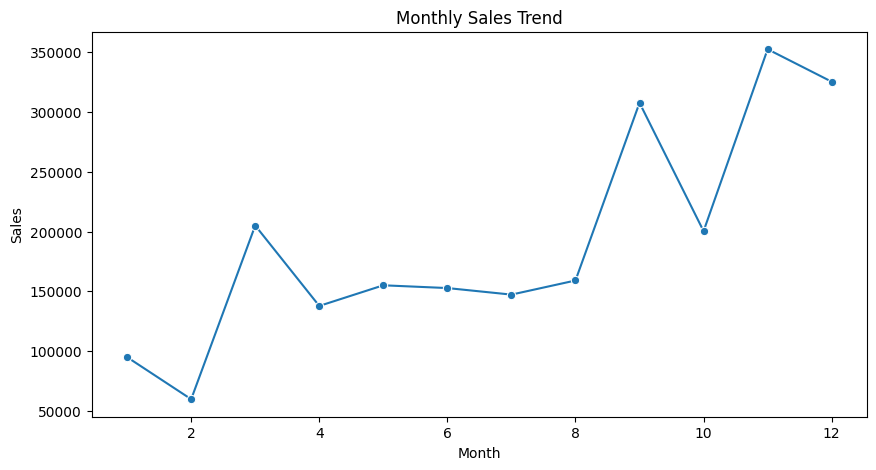

In [14]:
monthly_sales = data.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.show()

6. Top 10 States by Sales

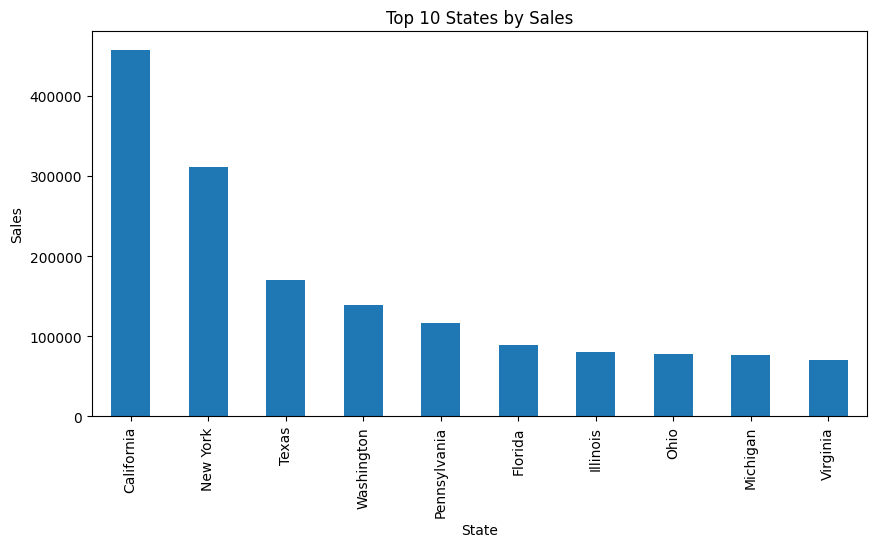

In [15]:
top_states = data.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

7. Sales Distribution

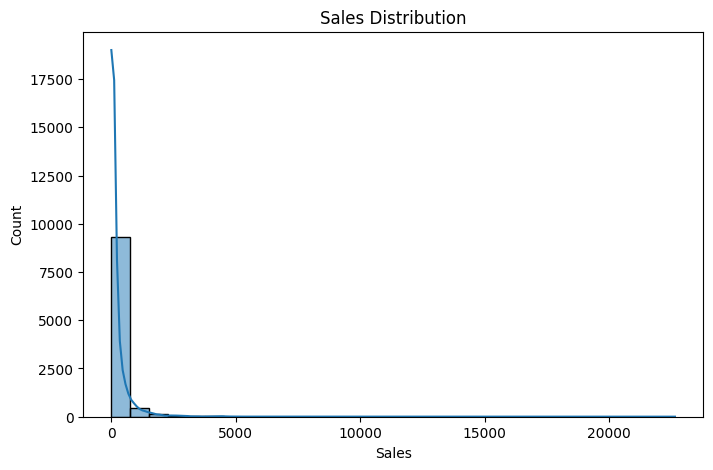

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data["Sales"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

8. Sales vs Profit

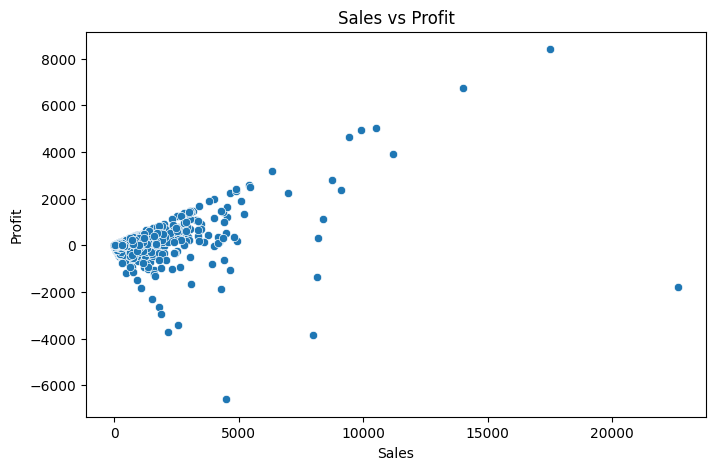

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.show()

**Feature Encoding**

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical = [
    'Ship Mode',
    'Segment',
    'Country',
    'City',
    'State',
    'Region',
    'Category',
    'Sub-Category',
    'Customer Type'
]

for col in categorical:
    data[col] = le.fit_transform(data[col])

**Feature selection**

In [19]:
X = data[['Category',
          'Sub-Category',
          'Region',
          'Discount',
          'Quantity',
          'Profit',
          'Month',
          'Shipping Days',
          'Profit Margin']]

y = data['Sales']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test,y_pred))
print("MSE :", mean_squared_error(y_test,y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score :", r2_score(y_test,y_pred))

MAE : 219.8185522497909
MSE : 467487.3300135441
RMSE : 683.7304512843816
R2 Score : 0.033631986513316336


**Random Forest Compare Model**

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2 Score :", r2_score(y_test, rf_pred))

Random Forest R2 Score : 0.687255627317271


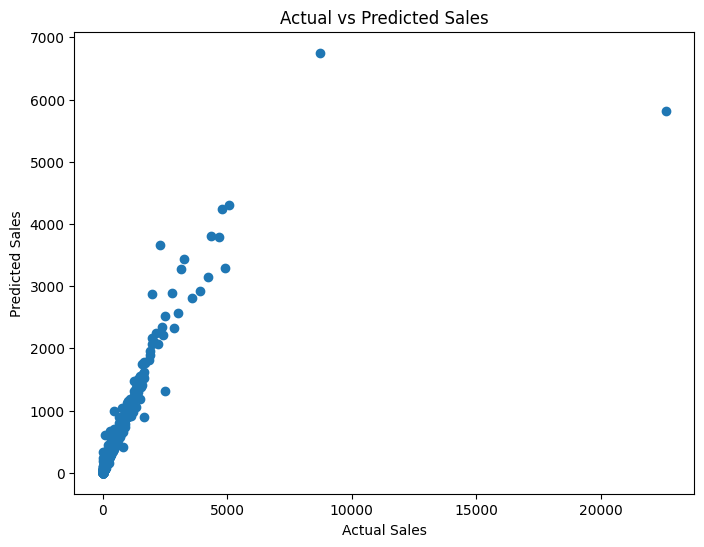

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()